Problem Statement

Classify Text Sentiment — Preprocess the text (lowercase, remove punctuation/stopwords, tokenize, stem or lemmatize), extract features using Bag-of-Words or TF-IDF, then train a text classification model (e.g. Naive Bayes or Logistic Regression) to predict the label. Report Accuracy and F1-score, and show the top 10 most important words per class.

Deliverables
Notebook with the full text-preprocessing pipeline
* TF-IDF (or BoW) feature matrix and a trained classifier
* Accuracy/F1 score + a short table of top predictive words per class

In [ ]:
# Imports and NLTK downloads
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Download required NLTK corpora
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# Load data and check distributions

df = pd.read_csv("IMDB Dataset.csv")

df.shape

df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [ ]:
# Define and apply preprocessing
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text: str) -> str:
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Lowercase
    text = text.lower()
    # 3. Remove punctuation, symbols, and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Tokenize by whitespace
    tokens = text.split()
    # 5. Remove stopwords and apply stemming
    cleaned_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    # 6. Reconstruct cleaned string
    return ' '.join(cleaned_tokens)

# Demonstration on a sample review
sample_raw = df['review'].iloc[0]
print("--- RAW TEXT SAMPLE ---")
print(sample_raw[:250], "...\n")
print("--- PREPROCESSED TEXT SAMPLE ---")
print(preprocess_text(sample_raw)[:250], "...\n")

# Apply pipeline across the entire 50,000 review corpus
print("Preprocessing full dataset (takes ~60-90 seconds)...")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Preprocessing completed.")

--- RAW TEXT SAMPLE ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of  ...

--- PREPROCESSED TEXT SAMPLE ---
one review mention watch oz episod youll hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam giv ...

Preprocessing full dataset (takes ~60-90 seconds)...
Preprocessing completed.


In [ ]:
# Train/test split and TF-IDF Vectorization
# Stratified 80/20 train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_review'],
    df['label'],
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

# Extract TF-IDF features (unigrams + bigrams, top 10,000 features, sublinear tf scaling)
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Testing feature matrix shape:  {X_test_tfidf.shape}")

Training feature matrix shape: (40000, 10000)
Testing feature matrix shape:  (10000, 10000)


=== Performance Comparison ===


,Model,Accuracy,F1-Score,Precision,Recall
0,Logistic Regression,0.8981,0.8988,0.8930,0.9046
1,Multinomial Naive Bayes,0.8664,0.8689,0.8531,0.8852



=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

    Negative     0.9033    0.8916    0.8974      5000
    Positive     0.8930    0.9046    0.8988      5000

    accuracy                         0.8981     10000
   macro avg     0.8982    0.8981    0.8981     10000
weighted avg     0.8982    0.8981    0.8981     10000



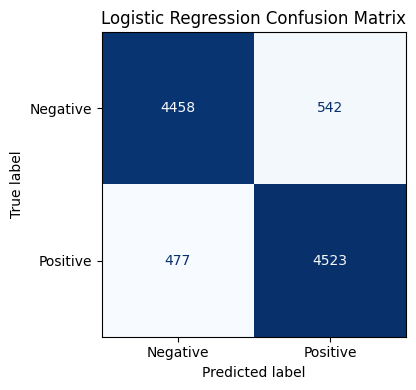

In [ ]:
# Model training and evaluation
# 1. Logistic Regression (Primary Model)
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

# 2. Multinomial Naive Bayes (Baseline Comparison)
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# Metrics calculation
metrics_data = {
    "Model": ["Logistic Regression", "Multinomial Naive Bayes"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_nb)],
    "F1-Score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_nb)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_nb)],
    "Recall": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_nb)]
}

metrics_df = pd.DataFrame(metrics_data)
print("=== Performance Comparison ===")
display(metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "F1-Score": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}"
}))

print("\n=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive'], digits=4))

# Plot Confusion Matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=['Negative', 'Positive'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)
ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

=== Top 10 Predictive Words per Class ===


,Rank,Top Negative Words,Negative Log-Odds,Top Positive Words,Positive Log-Odds
0,1,worst,-9.4081,excel,7.4607
1,2,wast,-8.2382,great,7.1563
2,3,aw,-8.2016,perfect,5.9634
3,4,bad,-7.5583,enjoy,5.2963
4,5,bore,-7.0411,amaz,5.0746
5,6,disappoint,-6.3959,hilari,4.9926
6,7,terribl,-6.0630,one best,4.4772
7,8,poor,-6.0454,brilliant,4.4741
8,9,fail,-5.4227,love,4.4513
9,10,noth,-5.3837,beauti,4.3842


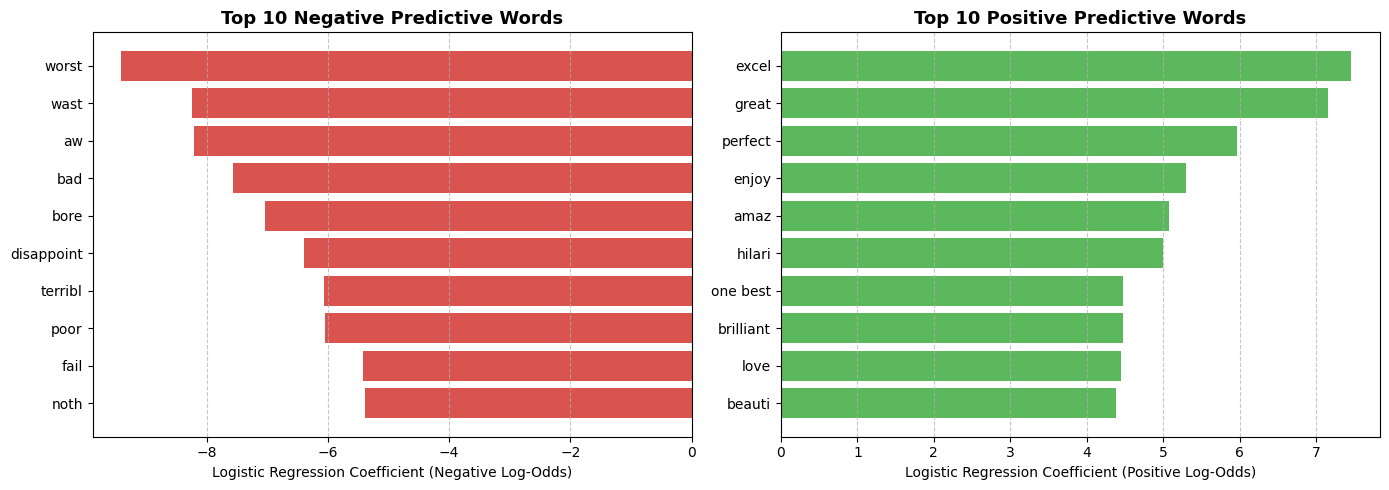

In [ ]:
# Feature importance extraction and visualization
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = lr_model.coef_[0]

# Negative class: lowest (most negative) coefficients
top_neg_indices = np.argsort(coefficients)[:10]
# Positive class: highest (most positive) coefficients
top_pos_indices = np.argsort(coefficients)[-10:][::-1]

top_neg_words = feature_names[top_neg_indices]
top_neg_weights = coefficients[top_neg_indices]

top_pos_words = feature_names[top_pos_indices]
top_pos_weights = coefficients[top_pos_indices]

# Tabulate results
importance_df = pd.DataFrame({
    "Rank": range(1, 11),
    "Top Negative Words": top_neg_words,
    "Negative Log-Odds": np.round(top_neg_weights, 4),
    "Top Positive Words": top_pos_words,
    "Positive Log-Odds": np.round(top_pos_weights, 4)
})

print("=== Top 10 Predictive Words per Class ===")
display(importance_df)

# Horizontal bar chart visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Negative Words Plot
axes[0].barh(top_neg_words[::-1], top_neg_weights[::-1], color='#d9534f')
axes[0].set_title("Top 10 Negative Predictive Words", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Logistic Regression Coefficient (Negative Log-Odds)")
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Positive Words Plot
axes[1].barh(top_pos_words[::-1], top_pos_weights[::-1], color='#5cb85c')
axes[1].set_title("Top 10 Positive Predictive Words", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Logistic Regression Coefficient (Positive Log-Odds)")
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Helper function for live inference
def predict_sentiment(review_text: str):
    cleaned = preprocess_text(review_text)
    vectorized = tfidf_vectorizer.transform([cleaned])
    prob = lr_model.predict_proba(vectorized)[0]
    pred = lr_model.predict(vectorized)[0]

    label = "Positive" if pred == 1 else "Negative"
    confidence = prob[pred] * 100

    return {
        "Prediction": label,
        "Confidence": f"{confidence:.2f}%",
        "Cleaned Text": cleaned
    }

# Test sample custom reviews
sample_reviews = [
    "This was an absolute masterpiece! Brilliant acting, tight pacing, and a breathtaking ending.",
    "A total waste of time. Boring script, terrible cinematography, and hollow acting."
]

for rev in sample_reviews:
    res = predict_sentiment(rev)
    print(f"Review: \"{rev}\"")
    print(f"--> Sentiment: {res['Prediction']} (Confidence: {res['Confidence']})\n")

Review: "This was an absolute masterpiece! Brilliant acting, tight pacing, and a breathtaking ending."
--> Sentiment: Positive (Confidence: 96.62%)

Review: "A total waste of time. Boring script, terrible cinematography, and hollow acting."
--> Sentiment: Negative (Confidence: 99.99%)

